- E/22/184 , E/22/151 , E/22/193 , E/22/320 , E/22/405
- Date - 7/30/2026
- Team - Tiramissu

In [1]:
!pip install -q torch torchvision opencv-python pandas scikit-learn matplotlib scikit-image

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import warnings
warnings.filterwarnings('ignore')
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    f1_score, precision_score, recall_score, ConfusionMatrixDisplay
)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
import matplotlib.pyplot as plt
import glob
import json
import random
from collections import Counter, defaultdict
import datetime

# --- Reproducibility (set before any model or data operations) ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- Optional: mount Google Drive if dataset is stored there ---
# from google.colab import drive
# drive.mount('/content/drive')

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# --- Hyperparameters ---
PATCH_SIZE          = 256
STRIDE              = 256      # non-overlapping: used for val / test
TRAIN_STRIDE        = 128      # overlapping: used for train (more patches per fold)
BATCH_SIZE          = 32
NUM_EPOCHS          = 20       # v2: was 12
LEARNING_RATE       = 1e-4
N_FOLDS             = 5
EARLY_STOP_PATIENCE = 6        # v2: was 4
TOP_K               = 3        # top-K mean patch aggregation -> whole-image prob
NUM_WORKERS         = 0        # 0 is safest in Colab/Kaggle; set to 2 on a local machine

# --- Dataset path detection (Kaggle- and Colab-compatible, unchanged from v1) ---
def detect_data_paths():
    candidate_roots = ['/kaggle/input', '/content/drive/MyDrive', '/content', '.']
    base_input_dir = '.'
    for kaggle_input in candidate_roots:
        if os.path.exists(kaggle_input):
            for root, dirs, files in os.walk(kaggle_input):
                dirs_lower = [d.lower() for d in dirs]
                if 'defect_free' in dirs_lower or 'defective' in dirs_lower or 'train' in dirs_lower:
                    base_input_dir = root
                    break
            else:
                continue
            break

    def find_dir(parent, target_names):
        if not os.path.exists(parent):
            return parent
        for item in os.listdir(parent):
            if item.lower() in [t.lower() for t in target_names] and os.path.isdir(os.path.join(parent, item)):
                return os.path.join(parent, item)
        return parent

    train_dir = find_dir(base_input_dir, ['train', 'Train'])
    test_dir  = find_dir(base_input_dir, ['test',  'Test'])
    sub_path  = os.path.join(base_input_dir, 'sample_submission.csv')
    if not os.path.exists(sub_path):
        matches = []
        for rc in candidate_roots:
            if os.path.exists(rc):
                matches += glob.glob(os.path.join(rc, '**', 'sample_submission.csv'), recursive=True)
        sub_path = matches[0] if matches else 'sample_submission.csv'
    return train_dir, test_dir, sub_path

TRAIN_DIR, TEST_DIR, submission_path = detect_data_paths()


# Outputs written directly to Kaggle working directory
OUTPUT_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
best_model_path = os.path.join(OUTPUT_DIR, "best_fabric_model.pth")
log_file = os.path.join(OUTPUT_DIR, "run_logs.txt")
output_submission_path = os.path.join(OUTPUT_DIR, "submission.csv")

metrics_path           = os.path.join(OUTPUT_DIR, 'validation_metrics.json')
baseline_results_path  = os.path.join(OUTPUT_DIR, 'baseline_results.json')

print(f'TRAIN_DIR         : {TRAIN_DIR}')
print(f'TEST_DIR          : {TEST_DIR}')
print(f'Sample submission : {submission_path}')
print(f'Output directory  : {OUTPUT_DIR}')

Using device: cuda
TRAIN_DIR         : /kaggle/input/competitions/co-5420-fabric-defect-detection-using-n-ns/CO5420 Fabric/Train
TEST_DIR          : /kaggle/input/competitions/co-5420-fabric-defect-detection-using-n-ns/CO5420 Fabric/Test
Sample submission : /kaggle/input/competitions/co-5420-fabric-defect-detection-using-n-ns/archive/sample_submission.csv
Output directory  : /kaggle/working


In [3]:
def collect_image_paths(base_train_dir, category_folder_names):
    valid_extensions = ('.png', '.jpg', '.jpeg', '.tif')
    found_paths = []
    if not os.path.exists(base_train_dir):
        return found_paths
    for root, dirs, files in os.walk(base_train_dir):
        folder_name = os.path.basename(root).lower()
        if any(cat.lower() == folder_name for cat in category_folder_names):
            for f in files:
                if f.lower().endswith(valid_extensions):
                    found_paths.append(os.path.join(root, f))
    return sorted(found_paths)

defect_free_paths = collect_image_paths(TRAIN_DIR, ['defect_free', 'defectfree'])
defective_paths   = collect_image_paths(TRAIN_DIR, ['defective'])

# Filter out mask files from defective_paths (they end in _mask.*)
defective_paths = [p for p in defective_paths
                   if not os.path.splitext(os.path.basename(p))[0].endswith('_mask')]

image_paths  = np.array(defect_free_paths + defective_paths)
image_labels = np.array([0] * len(defect_free_paths) + [1] * len(defective_paths))

print(f'Defect-free images : {len(defect_free_paths)}')
print(f'Defective images   : {len(defective_paths)}')
print(f'Total for {N_FOLDS}-fold CV : {len(image_paths)}')
print(f'Class ratio (defective): {np.mean(image_labels):.3f}')

Defect-free images : 99
Defective images   : 74
Total for 5-fold CV : 173
Class ratio (defective): 0.428


In [5]:
def get_patch_coordinates(image_shape, patch_size, stride):
    h, w = image_shape[:2]
    coords = []
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            coords.append((y, x))
    return coords


def find_corresponding_mask(img_path):
    # FIX v2: AITEX stores masks as {basename}_mask.png in the SAME directory.
    # v1 only searched subdirs (masks/, mask/, ...) and therefore found nothing.
    dir_name    = os.path.dirname(img_path)
    base_name   = os.path.basename(img_path)
    name_no_ext = os.path.splitext(base_name)[0]
    parent      = os.path.dirname(dir_name)
    valid_exts  = ('.png', '.jpg', '.jpeg', '.tif', '.bmp')

    # 1. Same directory, _mask suffix (AITEX standard format)
    for ext in valid_exts:
        candidate = os.path.join(dir_name, name_no_ext + '_mask' + ext)
        if os.path.exists(candidate):
            return candidate

    # 2. Sibling subdirectory patterns (fallback for other dataset layouts)
    for m_dir in [os.path.join(parent, 'masks'),
                  os.path.join(parent, 'mask'),
                  os.path.join(parent, 'defective_masks'),
                  os.path.join(dir_name, 'masks')]:
        if os.path.exists(m_dir):
            for ext in valid_exts:
                for suffix in ('', '_mask'):
                    candidate = os.path.join(m_dir, name_no_ext + suffix + ext)
                    if os.path.exists(candidate):
                        return candidate
    return None


class FabricPatchDataset(Dataset):
    def __init__(self, image_paths, labels, patch_size, stride,
                 transform=None, use_mask_guided_labels=True, verbose=True):
        self.patch_size   = patch_size
        self.transform    = transform
        self.patches_info = []   # (img_path, patch_label, y, x)
        self.image_cache  = {}
        masks_found = 0
        n_defective = sum(1 for l in labels if l == 1)

        if verbose:
            print('Loading images and extracting patch coordinates...')

        for img_path, img_label in zip(image_paths, labels):
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                print(f'  WARNING: could not read {img_path}')
                continue
            self.image_cache[img_path] = img
            coords = get_patch_coordinates(img.shape, patch_size, stride)

            mask_img = None
            if img_label == 1 and use_mask_guided_labels:
                mask_path = find_corresponding_mask(img_path)
                if mask_path:
                    mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                    if mask_img is not None:
                        masks_found += 1

            for y, x in coords:
                if img_label == 0:
                    patch_label = 0
                elif mask_img is not None:
                    mask_patch  = mask_img[y:y + patch_size, x:x + patch_size]
                    patch_label = 1 if np.count_nonzero(mask_patch > 0) > 0 else 0
                else:
                    patch_label = 1  # fallback: label whole image as defective
                self.patches_info.append((img_path, patch_label, y, x))

        if verbose:
            print(f'Masks found: {masks_found}/{n_defective} defective images')
            print(f'Total patches: {len(self.patches_info)}')
            dist = dict(Counter(info[1] for info in self.patches_info))
            print(f'Patch-level class distribution: {dist}')

    def __len__(self):
        return len(self.patches_info)

    def __getitem__(self, idx):
        img_path, label, y, x = self.patches_info[idx]
        img   = self.image_cache[img_path]
        patch = img[y:y + self.patch_size, x:x + self.patch_size]
        patch = cv2.cvtColor(patch, cv2.COLOR_GRAY2RGB)
        if self.transform:
            patch = self.transform(patch)
        return patch, label, img_path

In [6]:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10, fill=128),          # v2: reduced from 15 deg
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),  # v2: NEW
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize,
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.08), value=0.5),  # v2: NEW
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize,
])

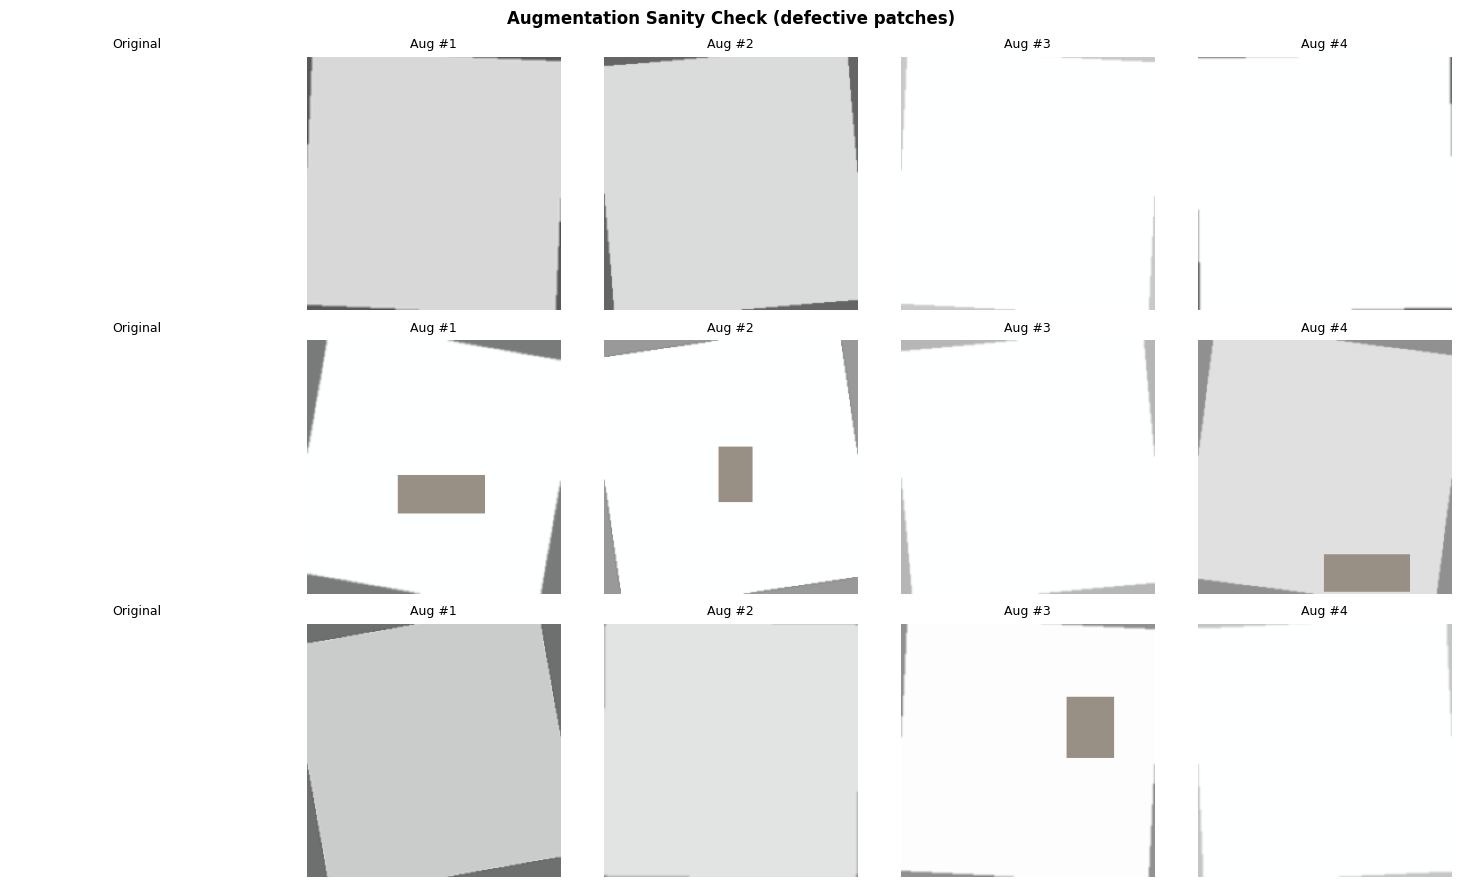

Saved: /kaggle/working/augmentation_check.png


In [7]:
def show_augmented_patches(img_paths, labels, n_images=3, n_aug=4):
    defective_paths_vis = [p for p, l in zip(img_paths, labels) if l == 1][:n_images]
    if not defective_paths_vis:
        print('No defective images found for augmentation check.')
        return
    fig, axes = plt.subplots(len(defective_paths_vis), n_aug + 1,
                             figsize=(3 * (n_aug + 1), 3 * len(defective_paths_vis)))
    if len(defective_paths_vis) == 1:
        axes = [axes]
    mean_np = np.array([0.485, 0.456, 0.406])
    std_np  = np.array([0.229, 0.224, 0.225])

    for row_idx, img_path in enumerate(defective_paths_vis):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        patch = img[:PATCH_SIZE, :PATCH_SIZE]
        patch_rgb = cv2.cvtColor(patch, cv2.COLOR_GRAY2RGB)
        # Original
        axes[row_idx][0].imshow(patch_rgb)
        axes[row_idx][0].set_title('Original', fontsize=9)
        axes[row_idx][0].axis('off')
        # Augmented versions
        for aug_idx in range(1, n_aug + 1):
            aug_tensor = train_transform(patch_rgb)
            aug_np = np.clip(aug_tensor.permute(1, 2, 0).numpy() * std_np + mean_np, 0, 1)
            axes[row_idx][aug_idx].imshow(aug_np)
            axes[row_idx][aug_idx].set_title(f'Aug #{aug_idx}', fontsize=9)
            axes[row_idx][aug_idx].axis('off')

    fig.suptitle('Augmentation Sanity Check (defective patches)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    aug_plot_path = os.path.join(OUTPUT_DIR, 'augmentation_check.png')
    plt.savefig(aug_plot_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved: {aug_plot_path}')

show_augmented_patches(image_paths.tolist(), image_labels.tolist())

In [8]:
def get_resnet34():
    model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer3.parameters():
        param.requires_grad = True
    for param in model.layer4.parameters():
        param.requires_grad = True
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_ftrs, 2))
    return model.to(device)


def get_efficientnet_b0():
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    # Unfreeze last 3 MBConv blocks (features[6], [7], [8]) + classifier
    for param in model.features[6].parameters():
        param.requires_grad = True
    for param in model.features[7].parameters():
        param.requires_grad = True
    for param in model.features[8].parameters():
        param.requires_grad = True
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(in_features, 2))
    return model.to(device)


# Quick sanity check
print('ResNet34     params trainable:',
      sum(p.numel() for p in get_resnet34().parameters() if p.requires_grad))
print('EfficientB0  params trainable:',
      sum(p.numel() for p in get_efficientnet_b0().parameters() if p.requires_grad))

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 160MB/s]


ResNet34     params trainable: 19937794
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 140MB/s] 


EfficientB0  params trainable: 3158302


In [10]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.35, gamma=1.5, reduction='mean'):
        super().__init__()
        self.alpha     = alpha
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt      = torch.exp(-ce_loss)
        alpha_t = torch.where(targets == 1, self.alpha, 1.0 - self.alpha)
        focal   = alpha_t * ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == 'mean':
            return focal.mean()
        elif self.reduction == 'sum':
            return focal.sum()
        return focal


def predict_probs_tta(model, loader, device):
    """4-view flip TTA. Returns ({img_path: [patch_probs]}, {img_path: label})."""
    model.eval()
    probs_by_img  = defaultdict(list)
    labels_by_img = {}
    with torch.no_grad():
        for patches, labels, paths in loader:
            patches = patches.to(device)
            views   = [
                patches,
                torch.flip(patches, dims=[3]),
                torch.flip(patches, dims=[2]),
                torch.flip(patches, dims=[2, 3]),
            ]
            probs_sum = None
            for v in views:
                p = torch.softmax(model(v), dim=1)[:, 1]
                probs_sum = p if probs_sum is None else probs_sum + p
            probs     = (probs_sum / len(views)).cpu().numpy()
            labels_np = labels.numpy() if torch.is_tensor(labels) else labels
            for path, prob, lab in zip(paths, probs, labels_np):
                probs_by_img[path].append(float(prob))
                labels_by_img[path] = int(lab)
    return probs_by_img, labels_by_img


def aggregate_topk(probs, k=TOP_K):
    return float(np.mean(sorted(probs, reverse=True)[:min(k, len(probs))]))


def sweep_threshold(probs_by_img, labels_by_img):
    agg = {p: aggregate_topk(v) for p, v in probs_by_img.items()}
    best_acc, best_t = -1.0, 0.5
    for t in np.arange(0.05, 0.95, 0.025):
        preds = [1 if agg[p] >= t else 0 for p in agg]
        labs  = [labels_by_img[p] for p in agg]
        acc   = accuracy_score(labs, preds)
        if acc > best_acc:
            best_acc, best_t = acc, float(t)
    return best_t, best_acc, agg


def train_one_fold(train_loader, train_dataset, val_loader, val_dataset,
                   fold_idx, model_factory=None, arch_name='CNN'):
    """Train one fold. model_factory: callable -> model. arch_name: label for printing."""
    if model_factory is None:
        model_factory = get_resnet34

    model     = model_factory()
    criterion = FocalLoss(alpha=0.35, gamma=1.5)

    # Separate backbone vs head learning rates (head trains faster)
    head_keywords   = ('fc', 'classifier')
    backbone_params = [p for n, p in model.named_parameters()
                       if p.requires_grad and not any(k in n for k in head_keywords)]
    head_params     = [p for n, p in model.named_parameters()
                       if p.requires_grad and any(k in n for k in head_keywords)]
    optimizer = optim.AdamW([
        {'params': backbone_params, 'lr': LEARNING_RATE * 0.2},
        {'params': head_params,     'lr': LEARNING_RATE},
    ], weight_decay=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
    scaler    = GradScaler()

    best_image_acc    = -1.0
    best_state        = None
    best_threshold    = 0.5
    epochs_no_improve = 0

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        for patches, labels, _ in train_loader:
            patches, labels = patches.to(device), labels.to(device)
            optimizer.zero_grad()
            with autocast():
                outputs = model(patches)
                loss    = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * patches.size(0)

        train_loss = running_loss / max(len(train_dataset), 1)
        probs_by_img, labels_by_img = predict_probs_tta(model, val_loader, device)
        thresh, image_acc, _ = sweep_threshold(probs_by_img, labels_by_img)
        print(f'  [{arch_name}] Fold {fold_idx} | Ep [{epoch+1:02d}/{NUM_EPOCHS}] '
              f'| Loss: {train_loss:.4f} | Val Acc (TTA): {image_acc:.4f} @ t={thresh:.3f}')
        scheduler.step()

        if image_acc > best_image_acc:
            best_image_acc    = image_acc
            best_threshold    = thresh
            best_state        = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= EARLY_STOP_PATIENCE:
                print(f'  [{arch_name}] Fold {fold_idx}: early stop at epoch {epoch+1}')
                break

    model.load_state_dict(best_state)
    save_path = os.path.join(OUTPUT_DIR, f'{arch_name.lower()}_fold{fold_idx}_model.pth')
    torch.save(best_state, save_path)
    return model, best_image_acc, best_threshold, save_path

In [11]:
# Pre-compute folds once; reused by all models
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_splits = list(skf.split(image_paths, image_labels))

rn_fold_models     = []
rn_fold_accuracies = []
rn_fold_thresholds = []
rn_oof_agg_probs   = {}   # {img_path: aggregated_prob} for ALL images (OOF)
rn_oof_labels      = {}   # {img_path: label}

for fold_idx, (train_idx, val_idx) in enumerate(fold_splits, start=1):
    sep = '=' * 60
    print(f'\n{sep}')
    print(f'RESNET34 -- FOLD {fold_idx}/{N_FOLDS}')
    print(sep)

    train_paths = image_paths[train_idx].tolist()
    train_labs  = image_labels[train_idx].tolist()
    val_paths   = image_paths[val_idx].tolist()
    val_labs    = image_labels[val_idx].tolist()

    train_ds = FabricPatchDataset(train_paths, train_labs, PATCH_SIZE, TRAIN_STRIDE,
                                   transform=train_transform, verbose=False)
    val_ds   = FabricPatchDataset(val_paths,   val_labs,   PATCH_SIZE, STRIDE,
                                   transform=val_transform,   verbose=False)

    # Weighted sampler to address patch-level class imbalance
    patch_labs     = [info[1] for info in train_ds.patches_info]
    cls_counts     = Counter(patch_labs)
    cls_wts        = {c: 1.0 / max(cls_counts[c], 1) for c in [0, 1]}
    sample_weights = [cls_wts[l] for l in patch_labs]
    sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                               num_workers=NUM_WORKERS)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS)

    model, acc, thresh, _ = train_one_fold(
        train_loader, train_ds, val_loader, val_ds,
        fold_idx, model_factory=get_resnet34, arch_name='ResNet34'
    )
    rn_fold_models.append(model)
    rn_fold_accuracies.append(acc)
    rn_fold_thresholds.append(thresh)
    print(f'--> ResNet34 Fold {fold_idx} best val acc: {acc:.4f} (t={thresh:.3f})')

    # Collect OOF predictions for this fold
    probs_by_img, labs_by_img = predict_probs_tta(model, val_loader, device)
    for p, plist in probs_by_img.items():
        rn_oof_agg_probs[p] = aggregate_topk(plist)
        rn_oof_labels[p]    = labs_by_img[p]

sep = '=' * 60
print(f'\n{sep}')
print(f'ResNet34 CV: {np.mean(rn_fold_accuracies):.4f} +/- {np.std(rn_fold_accuracies):.4f}')
print(f'Per-fold: {[round(a, 4) for a in rn_fold_accuracies]}')
print(f'OOF probs collected for {len(rn_oof_agg_probs)}/{len(image_paths)} images')


RESNET34 -- FOLD 1/5
  [ResNet34] Fold 1 | Ep [01/20] | Loss: 0.1700 | Val Acc (TTA): 0.7714 @ t=0.525
  [ResNet34] Fold 1 | Ep [02/20] | Loss: 0.1345 | Val Acc (TTA): 0.7143 @ t=0.450
  [ResNet34] Fold 1 | Ep [03/20] | Loss: 0.1204 | Val Acc (TTA): 0.8286 @ t=0.500
  [ResNet34] Fold 1 | Ep [04/20] | Loss: 0.1101 | Val Acc (TTA): 0.8286 @ t=0.475
  [ResNet34] Fold 1 | Ep [05/20] | Loss: 0.1025 | Val Acc (TTA): 0.8857 @ t=0.525
  [ResNet34] Fold 1 | Ep [06/20] | Loss: 0.0953 | Val Acc (TTA): 0.7714 @ t=0.525
  [ResNet34] Fold 1 | Ep [07/20] | Loss: 0.0906 | Val Acc (TTA): 0.8571 @ t=0.500
  [ResNet34] Fold 1 | Ep [08/20] | Loss: 0.0846 | Val Acc (TTA): 0.8571 @ t=0.500
  [ResNet34] Fold 1 | Ep [09/20] | Loss: 0.0876 | Val Acc (TTA): 0.9143 @ t=0.500
  [ResNet34] Fold 1 | Ep [10/20] | Loss: 0.0852 | Val Acc (TTA): 0.9429 @ t=0.550
  [ResNet34] Fold 1 | Ep [11/20] | Loss: 0.0827 | Val Acc (TTA): 0.9714 @ t=0.575
  [ResNet34] Fold 1 | Ep [12/20] | Loss: 0.0868 | Val Acc (TTA): 0.9429 @ t=

In [12]:
eff_fold_models     = []
eff_fold_accuracies = []
eff_fold_thresholds = []
eff_oof_agg_probs   = {}
eff_oof_labels      = {}

for fold_idx, (train_idx, val_idx) in enumerate(fold_splits, start=1):
    sep = '=' * 60
    print(f'\n{sep}')
    print(f'EFFICIENTNET-B0 -- FOLD {fold_idx}/{N_FOLDS}')
    print(sep)

    train_paths = image_paths[train_idx].tolist()
    train_labs  = image_labels[train_idx].tolist()
    val_paths   = image_paths[val_idx].tolist()
    val_labs    = image_labels[val_idx].tolist()

    train_ds = FabricPatchDataset(train_paths, train_labs, PATCH_SIZE, TRAIN_STRIDE,
                                   transform=train_transform, verbose=False)
    val_ds   = FabricPatchDataset(val_paths,   val_labs,   PATCH_SIZE, STRIDE,
                                   transform=val_transform,   verbose=False)

    patch_labs     = [info[1] for info in train_ds.patches_info]
    cls_counts     = Counter(patch_labs)
    cls_wts        = {c: 1.0 / max(cls_counts[c], 1) for c in [0, 1]}
    sample_weights = [cls_wts[l] for l in patch_labs]
    sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                               num_workers=NUM_WORKERS)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS)

    model, acc, thresh, _ = train_one_fold(
        train_loader, train_ds, val_loader, val_ds,
        fold_idx, model_factory=get_efficientnet_b0, arch_name='EffNetB0'
    )
    eff_fold_models.append(model)
    eff_fold_accuracies.append(acc)
    eff_fold_thresholds.append(thresh)
    print(f'--> EfficientNet-B0 Fold {fold_idx} best val acc: {acc:.4f} (t={thresh:.3f})')

    probs_by_img, labs_by_img = predict_probs_tta(model, val_loader, device)
    for p, plist in probs_by_img.items():
        eff_oof_agg_probs[p] = aggregate_topk(plist)
        eff_oof_labels[p]    = labs_by_img[p]

sep = '=' * 60
print(f'\n{sep}')
print(f'EfficientNet-B0 CV: {np.mean(eff_fold_accuracies):.4f} +/- {np.std(eff_fold_accuracies):.4f}')
print(f'Per-fold: {[round(a, 4) for a in eff_fold_accuracies]}')
print(f'OOF probs collected for {len(eff_oof_agg_probs)}/{len(image_paths)} images')


EFFICIENTNET-B0 -- FOLD 1/5
  [EffNetB0] Fold 1 | Ep [01/20] | Loss: 0.1199 | Val Acc (TTA): 0.7429 @ t=0.550
  [EffNetB0] Fold 1 | Ep [02/20] | Loss: 0.1108 | Val Acc (TTA): 0.8000 @ t=0.525
  [EffNetB0] Fold 1 | Ep [03/20] | Loss: 0.1072 | Val Acc (TTA): 0.7143 @ t=0.500
  [EffNetB0] Fold 1 | Ep [04/20] | Loss: 0.1018 | Val Acc (TTA): 0.7714 @ t=0.500
  [EffNetB0] Fold 1 | Ep [05/20] | Loss: 0.1006 | Val Acc (TTA): 0.7714 @ t=0.500
  [EffNetB0] Fold 1 | Ep [06/20] | Loss: 0.0978 | Val Acc (TTA): 0.7429 @ t=0.500
  [EffNetB0] Fold 1 | Ep [07/20] | Loss: 0.0981 | Val Acc (TTA): 0.7429 @ t=0.525
  [EffNetB0] Fold 1 | Ep [08/20] | Loss: 0.0965 | Val Acc (TTA): 0.7429 @ t=0.525
  [EffNetB0] Fold 1: early stop at epoch 8
--> EfficientNet-B0 Fold 1 best val acc: 0.8000 (t=0.525)

EFFICIENTNET-B0 -- FOLD 2/5
  [EffNetB0] Fold 2 | Ep [01/20] | Loss: 0.1189 | Val Acc (TTA): 0.7429 @ t=0.550
  [EffNetB0] Fold 2 | Ep [02/20] | Loss: 0.1100 | Val Acc (TTA): 0.7714 @ t=0.600
  [EffNetB0] Fold 2 |

## Section 6.5: Calibrate Single Global Threshold from Combined OOF Predictions
**v2**: combines ResNet34 and EfficientNet-B0 OOF probabilities (equal-weight average) before threshold sweep.
This gives us a single `GLOBAL_THRESHOLD` calibrated on the same probability scale as the 10-model ensemble used at test time — far more reliable than averaging five per-fold thresholds.

In [13]:
# Combine OOF probabilities: equal-weight average of both architectures
all_oof_agg_probs = {}
all_oof_labels    = {}
for p in rn_oof_agg_probs:
    rn_prob  = rn_oof_agg_probs[p]
    eff_prob = eff_oof_agg_probs.get(p, rn_prob)   # fallback to rn if eff missing
    all_oof_agg_probs[p] = (rn_prob + eff_prob) / 2.0
    all_oof_labels[p]    = rn_oof_labels[p]

# Sweep threshold on combined OOF
best_oof_acc, GLOBAL_THRESHOLD = -1.0, 0.5
for t in np.arange(0.05, 0.95, 0.025):
    preds = [1 if all_oof_agg_probs[p] >= t else 0 for p in all_oof_agg_probs]
    labs  = [all_oof_labels[p] for p in all_oof_agg_probs]
    acc   = accuracy_score(labs, preds)
    if acc > best_oof_acc:
        best_oof_acc, GLOBAL_THRESHOLD = acc, float(t)

oof_preds_final = [1 if all_oof_agg_probs[p] >= GLOBAL_THRESHOLD else 0
                   for p in all_oof_agg_probs]
oof_labs_final  = [all_oof_labels[p] for p in all_oof_agg_probs]

sep = '=' * 60
print(f'Combined OOF accuracy ({len(all_oof_agg_probs)} images): {best_oof_acc:.4f}')
print(f'GLOBAL_THRESHOLD: {GLOBAL_THRESHOLD:.3f}')
print(f'\n{sep}')
print('Combined OOF Confusion Matrix:')
print(confusion_matrix(oof_labs_final, oof_preds_final))
print('\nCombined OOF Classification Report:')
print(classification_report(oof_labs_final, oof_preds_final,
                            target_names=['Defect-free', 'Defective'], zero_division=0))

train_defect_ratio = float(np.mean(image_labels))
pred_defect_ratio  = float(np.mean(oof_preds_final))
print(f'Train defective ratio: {train_defect_ratio:.3f} | OOF predicted: {pred_defect_ratio:.3f}')
if abs(train_defect_ratio - pred_defect_ratio) > 0.15:
    print('WARNING: ratio mismatch -- threshold may be miscalibrated.')

# Pre-compute per-architecture OOF metrics (used in Section 8.5 comparison table)
rn_oof_pred_list = [1 if rn_oof_agg_probs.get(p, 0) >= GLOBAL_THRESHOLD else 0
                    for p in image_paths]
eff_oof_pred_list = [1 if eff_oof_agg_probs.get(p, 0) >= GLOBAL_THRESHOLD else 0
                     for p in image_paths]
cnn_ens_pred_list = [1 if all_oof_agg_probs.get(p, 0) >= GLOBAL_THRESHOLD else 0
                     for p in image_paths]
all_labs_list = image_labels.tolist()

Combined OOF accuracy (173 images): 0.8382
GLOBAL_THRESHOLD: 0.550

Combined OOF Confusion Matrix:
[[90  9]
 [19 55]]

Combined OOF Classification Report:
              precision    recall  f1-score   support

 Defect-free       0.83      0.91      0.87        99
   Defective       0.86      0.74      0.80        74

    accuracy                           0.84       173
   macro avg       0.84      0.83      0.83       173
weighted avg       0.84      0.84      0.84       173

Train defective ratio: 0.428 | OOF predicted: 0.370


In [14]:
if os.path.exists(submission_path) and os.path.exists(TEST_DIR):
    sub_df = pd.read_csv(submission_path)
    sub_df['ID'] = sub_df['ID'].str.strip()   # remove accidental whitespace
    test_image_paths  = [os.path.join(TEST_DIR, img_id) for img_id in sub_df['ID']]
    test_labels_dummy = [0] * len(test_image_paths)

    print('Creating test patch dataset...')
    test_dataset = FabricPatchDataset(
        test_image_paths, test_labels_dummy, PATCH_SIZE, STRIDE,
        transform=val_transform, use_mask_guided_labels=False, verbose=True
    )
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=NUM_WORKERS)

    all_models_named = ([(m, 'ResNet34') for m in rn_fold_models] +
                        [(m, 'EffNetB0') for m in eff_fold_models])

    print(f'\nRunning {len(all_models_named)}-model ensemble with TTA...')
    print(f'GLOBAL_THRESHOLD (from pooled OOF): {GLOBAL_THRESHOLD:.3f}')

    all_fold_agg_probs = []
    for i, (model, mname) in enumerate(all_models_named, start=1):
        print(f'  [{i:02d}/{len(all_models_named)}] {mname}...')
        probs_by_img, _ = predict_probs_tta(model, test_loader, device)
        agg = {p: aggregate_topk(v) for p, v in probs_by_img.items()}
        all_fold_agg_probs.append(agg)

    # Average across all models
    all_test_paths = list(all_fold_agg_probs[0].keys())
    ensemble_probs = {
        p: float(np.mean([fold[p] for fold in all_fold_agg_probs]))
        for p in all_test_paths
    }

    final_preds = []
    for img_id in sub_df['ID']:
        path = os.path.join(TEST_DIR, img_id.strip())
        prob = ensemble_probs.get(path, 0.0)
        final_preds.append(1 if prob >= GLOBAL_THRESHOLD else 0)

    sub_df['label'] = final_preds
    sub_df[['ID', 'label']].to_csv(output_submission_path, index=False)

    print(f'\nSubmission saved: {output_submission_path}')
    print('Prediction distribution:')
    print(sub_df['label'].value_counts().to_string())

    train_defect_ratio = float(np.mean(image_labels))
    pred_defect_ratio  = float(np.mean(final_preds))
    print(f'\nTrain defective ratio: {train_defect_ratio:.3f} | Test predicted: {pred_defect_ratio:.3f}')
    if abs(train_defect_ratio - pred_defect_ratio) > 0.15:
        print('WARNING: predicted ratio differs significantly -- double-check threshold.')

    with open(log_file, 'a') as f:
        f.write('\n' + '='*50 + '\n')
        f.write(f"Run: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f'Models: 5x ResNet34 + 5x EfficientNet-B0 (10 total)\n')
        f.write(f'ResNet34 CV: {np.mean(rn_fold_accuracies):.4f} +/- {np.std(rn_fold_accuracies):.4f}\n')
        f.write(f'EffNetB0 CV: {np.mean(eff_fold_accuracies):.4f} +/- {np.std(eff_fold_accuracies):.4f}\n')
        f.write(f'Combined OOF: {best_oof_acc:.4f}\n')
        f.write(f'GLOBAL_THRESHOLD: {GLOBAL_THRESHOLD:.3f}\n')
else:
    print(f"Skipping submission: '{submission_path}' or '{TEST_DIR}' not found.")

Creating test patch dataset...
Loading images and extracting patch coordinates...
Masks found: 0/0 defective images
Total patches: 1184
Patch-level class distribution: {0: 1184}

Running 10-model ensemble with TTA...
GLOBAL_THRESHOLD (from pooled OOF): 0.550
  [01/10] ResNet34...
  [02/10] ResNet34...
  [03/10] ResNet34...
  [04/10] ResNet34...
  [05/10] ResNet34...
  [06/10] EffNetB0...
  [07/10] EffNetB0...
  [08/10] EffNetB0...
  [09/10] EffNetB0...
  [10/10] EffNetB0...

Submission saved: /kaggle/working/submission.csv
Prediction distribution:
label
0    49
1    25

Train defective ratio: 0.428 | Test predicted: 0.338


In [15]:
def extract_glcm_features(img_gray):
    """GLCM texture features: 6 properties x (mean+std) = 12-dim vector."""
    img_u8  = np.clip(img_gray, 0, 255).astype(np.uint8)
    img_u8  = cv2.resize(img_u8, (256, 256), interpolation=cv2.INTER_AREA)
    glcm    = graycomatrix(img_u8, distances=[1, 3],
                           angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                           levels=256, symmetric=True, normed=True)
    feats = []
    for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']:
        vals = graycoprops(glcm, prop)
        feats.extend([float(vals.mean()), float(vals.std())])
    return np.array(feats, dtype=np.float32)


def extract_lbp_features(img_gray, P=24, R=3):
    """Uniform LBP histogram: P+2 = 26-dim vector."""
    img_u8 = np.clip(img_gray, 0, 255).astype(np.uint8)
    img_u8 = cv2.resize(img_u8, (256, 256), interpolation=cv2.INTER_AREA)
    lbp    = local_binary_pattern(img_u8, P=P, R=R, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=P + 2, range=(0, P + 2), density=True)
    return hist.astype(np.float32)


def extract_all_features(img_path):
    """Load image and return concatenated GLCM (12) + LBP (26) = 38-dim feature vector."""
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.zeros(38, dtype=np.float32)
    return np.concatenate([extract_glcm_features(img), extract_lbp_features(img)])


print('Extracting classical features (GLCM 12-dim + LBP 26-dim = 38-dim) for all labeled images...')
print('Images are resized to 256x256 before feature extraction for speed and consistency.')
all_features = np.vstack([extract_all_features(p) for p in image_paths])
print(f'Feature matrix shape: {all_features.shape}  (n_images x n_features)')

# 5-fold OOF SVM evaluation using the SAME fold_splits as the CNN
clf_oof_preds = np.zeros(len(image_paths), dtype=int)
clf_oof_probs = np.zeros(len(image_paths), dtype=float)
clf_fold_accs = []

print('\nTraining SVM with 5-fold OOF (same splits as CNN)...')
for fold_idx, (train_idx, val_idx) in enumerate(fold_splits, start=1):
    X_train, X_val = all_features[train_idx], all_features[val_idx]
    y_train, y_val = image_labels[train_idx], image_labels[val_idx]

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', probability=True,
                       class_weight='balanced',   # addresses 141 vs 106 imbalance
                       random_state=SEED))
    ])
    param_grid = {
        'clf__C':     [0.1, 1, 10, 100],
        'clf__gamma': ['scale', 0.001, 0.01, 0.1],
    }
    gs = GridSearchCV(pipe, param_grid, cv=3, scoring='accuracy', n_jobs=-1, refit=True)
    gs.fit(X_train, y_train)

    val_preds = gs.predict(X_val)
    val_probs = gs.predict_proba(X_val)[:, 1]
    clf_oof_preds[val_idx] = val_preds
    clf_oof_probs[val_idx] = val_probs
    fold_acc = accuracy_score(y_val, val_preds)
    clf_fold_accs.append(fold_acc)
    print(f'  SVM Fold {fold_idx}: val acc = {fold_acc:.4f} | best: {gs.best_params_}')

# Pooled OOF metrics
clf_accuracy  = accuracy_score(image_labels, clf_oof_preds)
clf_f1        = f1_score(image_labels, clf_oof_preds, average='macro', zero_division=0)
clf_precision = precision_score(image_labels, clf_oof_preds, average='macro', zero_division=0)
clf_recall    = recall_score(image_labels, clf_oof_preds, average='macro', zero_division=0)
clf_cm        = confusion_matrix(image_labels, clf_oof_preds)

sep = '=' * 60
print(f'\n{sep}')
print('Classical Baseline (GLCM + LBP + SVM) -- OOF Results')
print(f'{sep}')
print(f'CV per-fold: {[round(a, 4) for a in clf_fold_accs]}')
print(f'CV mean +/- std: {np.mean(clf_fold_accs):.4f} +/- {np.std(clf_fold_accs):.4f}')
print(f'Pooled OOF Accuracy  : {clf_accuracy:.4f}')
print(f'Pooled OOF F1 macro  : {clf_f1:.4f}')
print(f'Pooled OOF Precision : {clf_precision:.4f}')
print(f'Pooled OOF Recall    : {clf_recall:.4f}')
print(f'\nClassification Report:')
print(classification_report(image_labels, clf_oof_preds,
                            target_names=['Defect-free', 'Defective'], zero_division=0))
print('Confusion Matrix:')
print(clf_cm)

# Save results to JSON for project report
baseline_results = {
    'model'               : 'GLCM + LBP + SVM (RBF, class_weight=balanced)',
    'features'            : 'GLCM 12-dim + LBP uniform P=24 R=3 26-dim = 38 dims total',
    'protocol'            : f'{N_FOLDS}-fold OOF, same splits as CNN',
    'per_fold_accuracies' : [float(a) for a in clf_fold_accs],
    'cv_mean'             : float(np.mean(clf_fold_accs)),
    'cv_std'              : float(np.std(clf_fold_accs)),
    'oof_accuracy'        : float(clf_accuracy),
    'oof_f1_macro'        : float(clf_f1),
    'oof_precision_macro' : float(clf_precision),
    'oof_recall_macro'    : float(clf_recall),
    'confusion_matrix'    : clf_cm.tolist(),
}
with open(baseline_results_path, 'w') as f:
    json.dump(baseline_results, f, indent=2)
print(f'\nBaseline results saved: {baseline_results_path}')

Extracting classical features (GLCM 12-dim + LBP 26-dim = 38-dim) for all labeled images...
Images are resized to 256x256 before feature extraction for speed and consistency.
Feature matrix shape: (173, 38)  (n_images x n_features)

Training SVM with 5-fold OOF (same splits as CNN)...
  SVM Fold 1: val acc = 0.9143 | best: {'clf__C': 10, 'clf__gamma': 0.1}
  SVM Fold 2: val acc = 0.8286 | best: {'clf__C': 10, 'clf__gamma': 0.1}
  SVM Fold 3: val acc = 0.8286 | best: {'clf__C': 100, 'clf__gamma': 0.1}
  SVM Fold 4: val acc = 0.7941 | best: {'clf__C': 10, 'clf__gamma': 0.1}
  SVM Fold 5: val acc = 0.9118 | best: {'clf__C': 10, 'clf__gamma': 0.1}

Classical Baseline (GLCM + LBP + SVM) -- OOF Results
CV per-fold: [0.9143, 0.8286, 0.8286, 0.7941, 0.9118]
CV mean +/- std: 0.8555 +/- 0.0487
Pooled OOF Accuracy  : 0.8555
Pooled OOF F1 macro  : 0.8497
Pooled OOF Precision : 0.8598
Pooled OOF Recall    : 0.8447

Classification Report:
              precision    recall  f1-score   support

 Defec

MODEL COMPARISON -- Out-of-Fold Validation (all labeled images)
Model                                  Accuracy  F1 macro  Precision   Recall
----------------------------------------------------------------------------
Classical (GLCM+LBP+SVM)                 0.8555    0.8497     0.8598   0.8447
ResNet34  (5-fold, TTA)                  0.8497    0.8447     0.8503   0.8414
EfficientNet-B0 (5-fold, TTA)            0.7399    0.7252     0.7413   0.7215
CNN Ensemble (10 models, TTA)            0.8382    0.8312     0.8425   0.8262

All metrics saved: /kaggle/working/validation_metrics.json


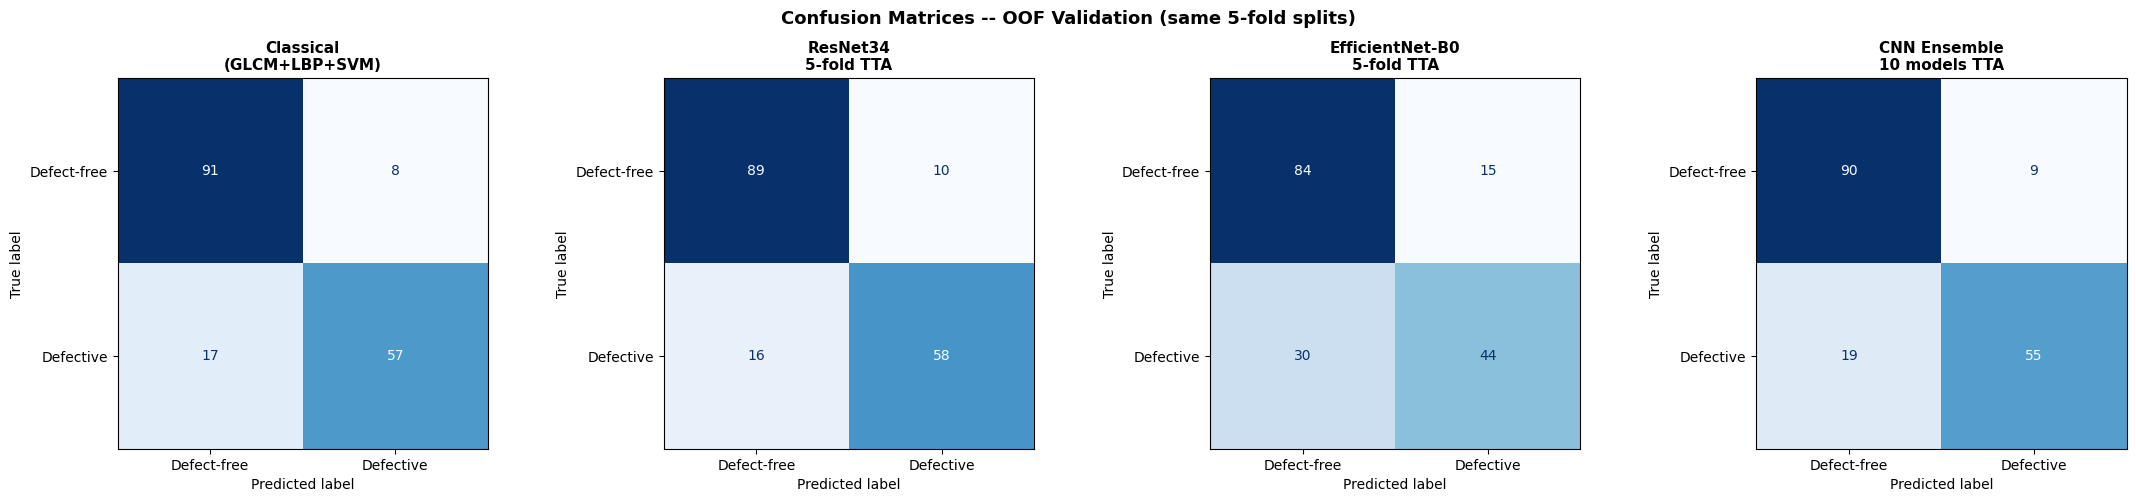

Confusion matrices saved: /kaggle/working/confusion_matrices.png


In [16]:
def compute_metrics(preds, labs):
    return {
        'accuracy'        : float(accuracy_score(labs, preds)),
        'f1_macro'        : float(f1_score(labs, preds, average='macro', zero_division=0)),
        'precision_macro' : float(precision_score(labs, preds, average='macro', zero_division=0)),
        'recall_macro'    : float(recall_score(labs, preds, average='macro', zero_division=0)),
        'f1_defect_free'  : float(f1_score(labs, preds, pos_label=0, zero_division=0)),
        'f1_defective'    : float(f1_score(labs, preds, pos_label=1, zero_division=0)),
    }

clf_metrics = compute_metrics(list(clf_oof_preds), all_labs_list)
rn_metrics  = compute_metrics(rn_oof_pred_list,    all_labs_list)
eff_metrics = compute_metrics(eff_oof_pred_list,   all_labs_list)
cnn_metrics = compute_metrics(cnn_ens_pred_list,   all_labs_list)

sep = '=' * 76
print(sep)
print('MODEL COMPARISON -- Out-of-Fold Validation (all labeled images)')
print(sep)
header = f"{'Model':<38} {'Accuracy':>8} {'F1 macro':>9} {'Precision':>10} {'Recall':>8}"
print(header)
print('-' * 76)

def print_row(name, m):
    print(f"{name:<38} {m['accuracy']:>8.4f} {m['f1_macro']:>9.4f} "
          f"{m['precision_macro']:>10.4f} {m['recall_macro']:>8.4f}")

print_row('Classical (GLCM+LBP+SVM)',          clf_metrics)
print_row('ResNet34  (5-fold, TTA)',            rn_metrics)
print_row('EfficientNet-B0 (5-fold, TTA)',      eff_metrics)
print_row('CNN Ensemble (10 models, TTA)',      cnn_metrics)
print(sep)

# Save all metrics
all_validation_metrics = {
    'global_threshold'     : float(GLOBAL_THRESHOLD),
    'classical_svm'        : clf_metrics,
    'resnet34_5fold'       : rn_metrics,
    'efficientnet_b0_5fold': eff_metrics,
    'cnn_ensemble_10model' : cnn_metrics,
}
with open(metrics_path, 'w') as f:
    json.dump(all_validation_metrics, f, indent=2)
print(f'\nAll metrics saved: {metrics_path}')

# Confusion matrix plots
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
configs = [
    ('Classical\n(GLCM+LBP+SVM)',      list(clf_oof_preds)),
    ('ResNet34\n5-fold TTA',            rn_oof_pred_list),
    ('EfficientNet-B0\n5-fold TTA',     eff_oof_pred_list),
    ('CNN Ensemble\n10 models TTA',     cnn_ens_pred_list),
]
for ax, (title, preds) in zip(axes, configs):
    cm   = confusion_matrix(all_labs_list, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Defect-free', 'Defective'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11, fontweight='bold')

fig.suptitle('Confusion Matrices -- OOF Validation (same 5-fold splits)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
cm_path = os.path.join(OUTPUT_DIR, 'confusion_matrices.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Confusion matrices saved: {cm_path}')